In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

options = ['A', 'B', 'C', 'D', 'E']

In [4]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
display(train.head(2))

Train shape: (2000, 8)
Test shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A


In [5]:
display(train.describe())
display(train.info())

,id
count,2000.000000
mean,1000.500000
std,577.494589
min,1.000000
25%,500.750000
50%,1000.500000
75%,1500.250000
max,2000.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


None

In [6]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


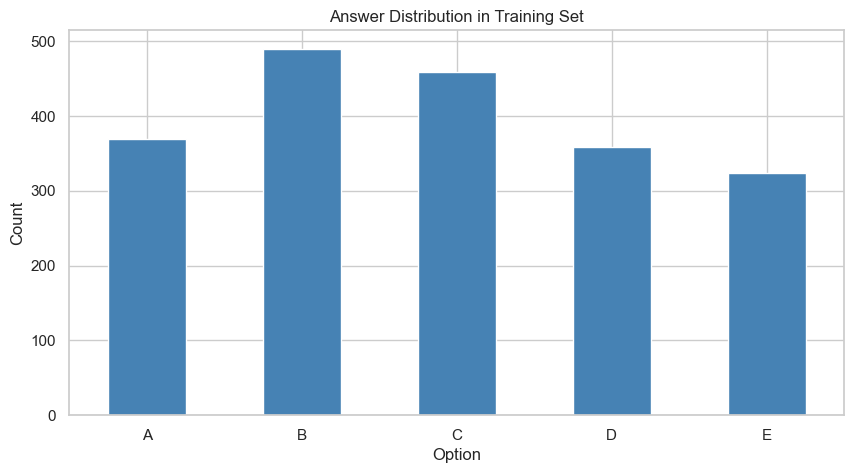

In [3]:
train['answer'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Answer Distribution in Training Set')
plt.xlabel('Option')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

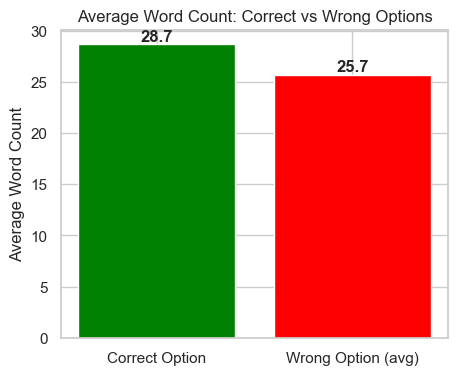

In [7]:
train['correct_option_len'] = train.apply(lambda row: len(str(row[row['answer']]).split()), axis=1)
train['wrong_option_len'] = train.apply(
    lambda row: np.mean([len(str(row[opt]).split()) for opt in options if opt != row['answer']]), axis=1)

avg_correct = train['correct_option_len'].mean()
avg_wrong = train['wrong_option_len'].mean()

plt.figure(figsize=(5, 4))
plt.bar(['Correct Option', 'Wrong Option (avg)'], [avg_correct, avg_wrong], color=['green', 'red'])
plt.title('Average Word Count: Correct vs Wrong Options')
plt.ylabel('Average Word Count')
for i, v in enumerate([avg_correct, avg_wrong]):
    plt.text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
plt.show()